Loading peak F1 from results CSVs...
  215: peak_F1=0.978
  213: peak_F1=0.343
  209: peak_F1=0.920
  203: peak_F1=0.534
  210: peak_F1=0.886
  116: peak_F1=0.917
  222: peak_F1=0.314
  233: peak_F1=0.970
  118: peak_F1=0.678
  223: peak_F1=0.796
  221: peak_F1=0.971
  214: peak_F1=0.962
  200: peak_F1=0.623
  228: peak_F1=0.857
  201: peak_F1=0.497
  208: peak_F1=0.621
  119: peak_F1=0.959
  207: peak_F1=0.376
  106: peak_F1=0.932

Loading arrhythmia type counts...


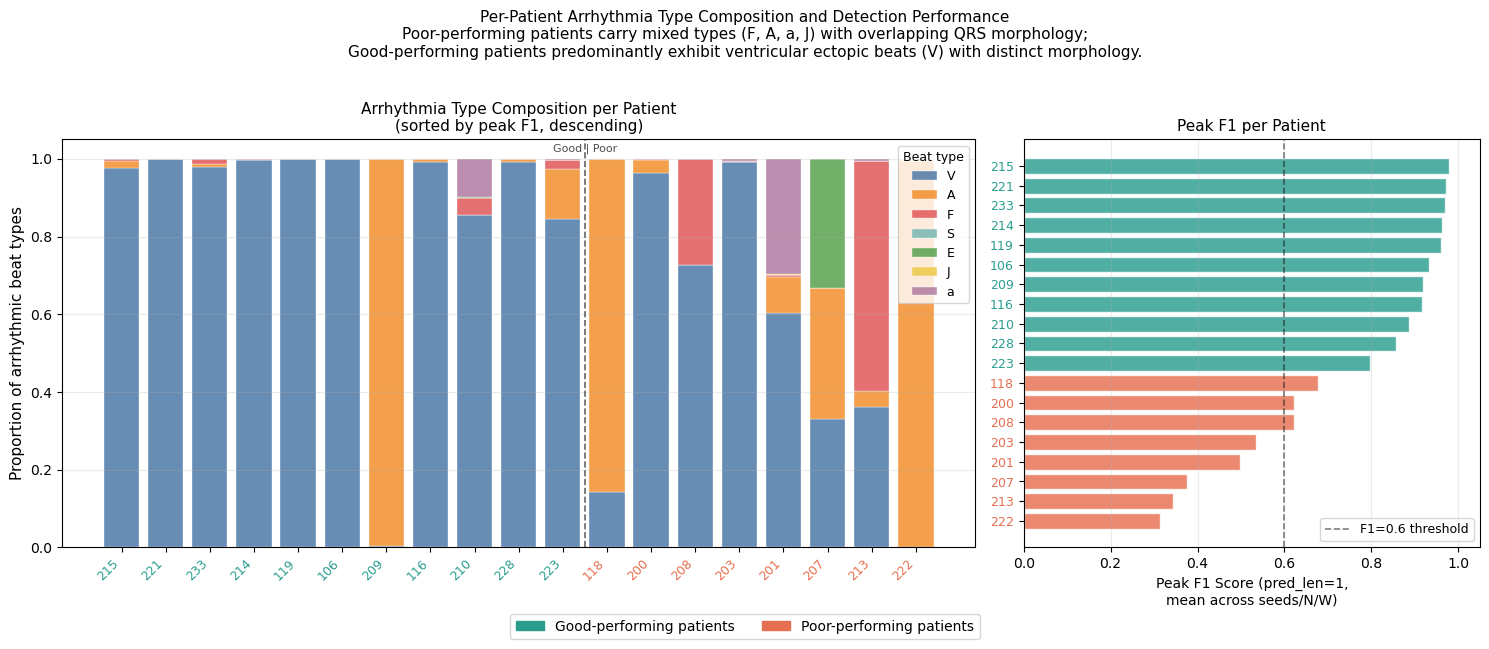

Saved FigS6_arrtype_vs_F1


In [1]:
#!/usr/bin/env python
# coding: utf-8

# ==========================================================
# SUPPLEMENTARY FIGURE S6
# Arrhythmia type composition per patient alongside peak F1
# Uses:
#   - arr_types from HDBSCAN analysis (already computed)
#   - peak F1 from your main results CSVs
# ==========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
from collections import Counter

# ==========================================================
# CONFIG
# ==========================================================

selected_patients = [
    '215','213','209','203','210','116','222','233',
    '118','223','221','214','200','228','201','208',
    '119','207','106'
]

GOOD_PATIENTS = ['119','116','221','228','106','215','209',
                 '210','233','223','214']
POOR_PATIENTS = ['118','200','201','203','207','208','213','222']

annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'
data_folder       = 'mitdb_data_full'
results_dir       = 'results_all_selected_patients_w1-10_N'

ARRHYTHMIC_BEATS  = ['A','a','J','S','V','E','F']
NORMAL_BEATS      = ['.','N','L','R','e','j']

beat_length       = 180

fig_dir = "figures_NA_separation"
os.makedirs(fig_dir, exist_ok=True)

# ==========================================================
# STEP 1 — Get peak F1 from existing results CSVs
# ==========================================================

def get_peak_f1(record, results_dir):
    """Mean peak F1 across all seeds, input_lens, N for pred_len=1."""
    peak_f1s = []
    for f in os.listdir(results_dir):
        if not f.endswith('.csv'):
            continue
        # match patient in filename
        if '_{}_'.format(record) not in f and \
           'patient_{}_'.format(record) not in f:
            continue
        try:
            df = pd.read_csv(os.path.join(results_dir, f))
            # use pred_len=1 for consistency
            df1 = df[df["Pred_len"] == 1] if "Pred_len" in df.columns else df
            for _, row in df1.iterrows():
                res = json.loads(row["Online_results"])
                f1s = [r["f1"] for r in res]
                if f1s:
                    peak_f1s.append(max(f1s))
        except Exception:
            pass
    return float(np.mean(peak_f1s)) if peak_f1s else np.nan

print("Loading peak F1 from results CSVs...")
peak_f1_dict = {}
for pat in selected_patients:
    peak_f1_dict[pat] = get_peak_f1(pat, results_dir)
    print("  {}: peak_F1={:.3f}".format(pat, peak_f1_dict[pat]))

# ==========================================================
# STEP 2 — Get arrhythmia type counts from annotations
# ==========================================================

print("\nLoading arrhythmia type counts...")
arr_data = {}
for pat in selected_patients:
    try:
        ann = wfdb.rdann(
            os.path.join(annotation_folder, pat), extension='atr')
        counts = Counter(
            sym for sym in ann.symbol if sym in ARRHYTHMIC_BEATS)
        total  = sum(counts.values())
        arr_data[pat] = {"counts": counts, "total": total}
    except Exception as e:
        print("  Skipping {}: {}".format(pat, e))
        arr_data[pat] = {"counts": Counter(), "total": 0}

# ==========================================================
# STEP 3 — Sort by peak F1 descending
# ==========================================================

sorted_pats = sorted(
    selected_patients,
    key=lambda p: peak_f1_dict.get(p, 0),
    reverse=True
)

# ==========================================================
# FIGURE — Two-panel: stacked bar (left) + peak F1 (right)
# ==========================================================

beat_types   = ['V', 'A', 'F', 'S', 'E', 'J', 'a']
colors_bt    = {
    'V': '#4e79a7', 'A': '#f28e2b', 'F': '#e15759',
    'S': '#76b7b2', 'E': '#59a14f', 'J': '#edc948', 'a': '#b07aa1'
}

fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={'width_ratios': [2, 1]}
)

# ---- Left: stacked bar of arrhythmia type proportions ----
ax  = axes[0]
x   = np.arange(len(sorted_pats))
bottom = np.zeros(len(sorted_pats))

for bt in beat_types:
    proportions = []
    for p in sorted_pats:
        total = arr_data[p]["total"] if arr_data[p]["total"] > 0 else 1
        proportions.append(arr_data[p]["counts"].get(bt, 0) / total)
    ax.bar(x, proportions, bottom=bottom,
           color=colors_bt[bt], label=bt, alpha=0.85, edgecolor='white',
           linewidth=0.3)
    bottom += np.array(proportions)

ax.set_xticks(x)
ax.set_xticklabels(sorted_pats, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Proportion of arrhythmic beat types", fontsize=11)
ax.set_title("Arrhythmia Type Composition per Patient\n"
             "(sorted by peak F1, descending)", fontsize=11)
ax.legend(title="Beat type", fontsize=9, loc='upper right',
          title_fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.25)

# Colour x-tick labels by group
for tick, pat in zip(ax.get_xticklabels(), sorted_pats):
    tick.set_color("#2a9d8f" if pat in GOOD_PATIENTS else "#e76f51")

# Dividing line between good/poor region
n_good_sorted = sum(1 for p in sorted_pats if p in GOOD_PATIENTS)
ax.axvline(n_good_sorted - 0.5, color='black',
           linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(n_good_sorted - 0.5, 1.02, 'Good | Poor',
        ha='center', fontsize=8, color='black', alpha=0.7)

# ---- Right: peak F1 horizontal bar ----
ax2   = axes[1]
f1s   = [peak_f1_dict.get(p, np.nan) for p in sorted_pats]
clrs  = ["#2a9d8f" if p in GOOD_PATIENTS else "#e76f51"
          for p in sorted_pats]

bars  = ax2.barh(x, f1s, color=clrs, alpha=0.82, edgecolor='white')
ax2.set_yticks(x)
ax2.set_yticklabels(sorted_pats, fontsize=9)
ax2.set_xlabel("Peak F1 Score (pred_len=1,\nmean across seeds/N/W)", fontsize=10)
ax2.set_title("Peak F1 per Patient", fontsize=11)
ax2.axvline(0.6, color='black', linestyle='--',
            linewidth=1.2, alpha=0.5, label='F1=0.6 threshold')
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()
ax2.legend(fontsize=9)
ax2.grid(True, axis='x', alpha=0.25)

# Colour y-tick labels by group
for ytick, pat in zip(ax2.get_yticklabels(), sorted_pats):
    ytick.set_color("#2a9d8f" if pat in GOOD_PATIENTS else "#e76f51")

# Shared legend for patient groups
handles_grp = [
    mpatches.Patch(color="#2a9d8f", label="Good-performing patients"),
    mpatches.Patch(color="#e76f51", label="Poor-performing patients"),
]
fig.legend(handles=handles_grp, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    "Per-Patient Arrhythmia Type Composition and Detection Performance\n"
    "Poor-performing patients carry mixed types (F, A, a, J) with "
    "overlapping QRS morphology;\n"
    "Good-performing patients predominantly exhibit ventricular "
    "ectopic beats (V) with distinct morphology.",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "FigS6_arrtype_vs_F1.pdf"),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(fig_dir, "FigS6_arrtype_vs_F1.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved FigS6_arrtype_vs_F1")